In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os
%matplotlib inline
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from numpy.linalg import inv
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import networkx as nx
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:

# reading the qc file 
qc_data = pd.read_excel(
    r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\QC_msmetrix.xlsx",
    sheet_name=0,
    header=12
)

print(qc_data.head())

   Peak    tR1    tR2     tR  m/z  \
0     1  1.864  1.949  1.906   40   
1     2  1.905  1.991  1.948   44   
2     3  1.925  2.003  1.964   81   
3     4  1.940  2.039  1.990   64   
4     5  1.960  2.090  2.025   42   

                                            ID Names  s1 S96_QC1_B1_D1_T1  \
0    0.15%  || 40                                ...                44728   
1    1.81%  || 44                                ...               354392   
2    0.14%  || 81   69  169  119                 ...                75703   
3    0.80%  || 64   48   61   66   96   37  131  ...               238856   
4    0.82%  || 42  41  40  39  38  50            ...               207592   

   s2 S96_QC2_B1_D1_T1  s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  ...  \
0                46928                46096                44488  ...   
1               461936               609704                92652  ...   
2                27041                69053                62942  ...   
3               296333

In [ ]:
# Clean column names (remove spaces)
qc_data.columns = qc_data.columns.str.strip()

# consider Metadata columns
metadata_cols = ['Peak', 'tR1', 'tR2', 'tR', 'm/z']

# Select columns that end with "T1"
t1_cols = [c for c in qc_data.columns if c.strip().endswith("T1")]

# Combine metadata + T1 columns
qc_data_T1 = qc_data[metadata_cols + t1_cols]

# Show results
print("Selected T1 sample columns:")
print(t1_cols)
print("\nFiltered DataFrame shape:", qc_data_T1.shape)
print(qc_data_T1.head())

Selected T1 sample columns:
['s1 S96_QC1_B1_D1_T1', 's2 S96_QC2_B1_D1_T1', 's3 S96_QC3_B1_D1_T1', 's4 S96_QC4_B1_D1_T1', 's5 S96_QC1_B1_D2_T1', 's6 S96_QC2_B1_D2_T1', 's7 S96_QC3_B1_D2_T1', 's8 S96_QC4_B1_D2_T1', 's9 S96_QC1_B1_D3_T1', 's10 S96_QC2_B1_D3_T1', 's11 S96_QC3_B1_D3_T1', 's12 S96_QC4_B1_D3_T1', 's13 S96_QC2_B1_D4_T1', 's14 S96_QC3_B1_D4_T1', 's15 S96_QC4_B1_D4_T1', 's16 S96_QC1_B1_D4_T1', 's17 S96_QC1_B1_D5_T1', 's18 S96_QC1_B1_D9_T1', 's19 S96_QC2_B1_D5_T1', 's20 S96_QC2_B1_D9_T1', 's21 S96_QC3_B1_D5_T1', 's22 S96_QC3_B1_D9_T1', 's23 S96_QC4_B1_D5_T1', 's24 S96_QC4_B1_D9_T1', 's25 S96_QC1_B1_D10_T1', 's26 S96_QC1_B1_D6_T1', 's27 S96_QC1_B1_D7_T1', 's28 S96_QC1_B1_D8_T1', 's29 S96_QC3_B1_D10_T1', 's30 S96_QC3_B1_D6_T1', 's31 S96_QC3_B1_D7_T1', 's32 S96_QC4_B1_D10_T1', 's33 S96_QC4_B1_D6_T1', 's34 S96_QC4_B1_D7_T1', 's35 S96_QC2_B1_D8_T1', 's36 S96_QC3_B1_D8_T1', 's37 S96_QC4_B1_D8_T1', 's38 S96_QC2_B1_D10_T1', 's39 S96_QC2_B1_D6_T1', 's40 S96_QC2_B1_D7_T1']

Filtered DataFr

In [4]:
# we got the information of qcdata to see more details
qc_data_T1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589 entries, 0 to 588
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Peak                   589 non-null    int64  
 1   tR1                    589 non-null    float64
 2   tR2                    589 non-null    float64
 3   tR                     589 non-null    float64
 4   m/z                    589 non-null    int64  
 5   s1 S96_QC1_B1_D1_T1    589 non-null    int64  
 6   s2 S96_QC2_B1_D1_T1    589 non-null    int64  
 7   s3 S96_QC3_B1_D1_T1    589 non-null    int64  
 8   s4 S96_QC4_B1_D1_T1    589 non-null    int64  
 9   s5 S96_QC1_B1_D2_T1    589 non-null    int64  
 10  s6 S96_QC2_B1_D2_T1    589 non-null    int64  
 11  s7 S96_QC3_B1_D2_T1    589 non-null    int64  
 12  s8 S96_QC4_B1_D2_T1    589 non-null    int64  
 13  s9 S96_QC1_B1_D3_T1    589 non-null    int64  
 14  s10 S96_QC2_B1_D3_T1   589 non-null    int64  
 15  s11 S9

In [5]:

# getting differences between retention time beacuse we want to have just one retention time
diff_t_vs_1 = (qc_data_T1['tR'] -qc_data_T1['tR1']).abs()
diff_t_vs_2 = (qc_data_T1['tR'] - qc_data_T1['tR2']).abs()
diff_1_vs_2 = (qc_data_T1['tR1'] -qc_data_T1['tR2']).abs()
avg_t   = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2
diff_avg_vs_t = (avg_t - qc_data['tR']).abs()

# printing the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    589.000000
mean       0.033163
std        0.018089
min        0.015000
25%        0.021000
50%        0.027000
75%        0.039000
max        0.141000
dtype: float64 

abs(tR - tR2):
 count    589.000000
mean       0.033136
std        0.018078
min        0.015000
25%        0.021000
50%        0.027000
75%        0.038000
max        0.141000
dtype: float64 

abs(tR1 - tR2):
 count    589.000000
mean       0.066299
std        0.036161
min        0.030000
25%        0.042000
50%        0.053000
75%        0.077000
max        0.282000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    5.890000e+02
mean     2.393888e-04
std      2.499870e-04
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      5.000000e-04
max      5.000000e-04
dtype: float64 



In [ ]:
# put tr_best instead of other tr
qc_data_T1['tR_best'] = (qc_data_T1['tR1'] + qc_data_T1['tR2']) / 2

# removing unnecessary columns
to_keep = [col for col in qc_data_T1.columns if col not in ['tR1', 'tR2', 'tR']]
cleaned_qc = qc_data_T1[to_keep]

# Confirm that 'tR_best' is included
print("tR_best column saved:", 'tR_best' in cleaned_qc.columns)

cols = cleaned_qc.columns.tolist()
# Moving 'tR_best' after 'Peak'
cols.insert(cols.index('Peak') + 1, cols.pop(cols.index('tR_best')))

# Reorder the DataFrame
cleaned_qc = cleaned_qc[cols]
# Check the result
print(cleaned_qc.head())
# Save cleaned data with tR_best
cleaned_qc.to_csv(r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\cleaned_qc.csv", index=False)
# now this cleaned_qc datafram can be used for further analysis

tR_best column saved: True
   Peak  tR_best  m/z  s1 S96_QC1_B1_D1_T1  s2 S96_QC2_B1_D1_T1  \
0     1   1.9065   40                44728                46928   
1     2   1.9480   44               354392               461936   
2     3   1.9640   81                75703                27041   
3     4   1.9895   64               238856               296333   
4     5   2.0250   42               207592               197912   

   s3 S96_QC3_B1_D1_T1  s4 S96_QC4_B1_D1_T1  s5 S96_QC1_B1_D2_T1  \
0                46096                44488                47288   
1               609704                92652               326936   
2                69053                62942                41856   
3               363394               280169               239716   
4               201184               105097               226030   

   s6 S96_QC2_B1_D2_T1  s7 S96_QC3_B1_D2_T1  ...  s31 S96_QC3_B1_D7_T1  \
0                46560                45104  ...                 45912   
1            

In [ ]:
# Load data
input_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\final_sample_1-10.xlsx"
df_raw = pd.read_excel(input_path, header=None)

# Find the header row that contains "Peak"
header_row = df_raw[df_raw.iloc[:, 0].astype(str).str.strip() == "Peak"].index[0]
potato_data = pd.read_excel(input_path, header=header_row)

# Metadata columns to keep
metadata_cols = ['Peak', 'tR1', 'tR2', 'tR', 'm/z']

# Define normalized list of sample IDs you want to keep 
final_normalized_ids = [
    'S96_10_B1_D2_T1', 'S96_11_B1_D10_T1', 'S96_12_B1_D5_T1', 'S96_13_B1_D9_T1',
    'S96_14_B1_D1_T1', 'S96_15_B1_D6_T1', 'S96_16_B1_D3_T1', 'S96_17_B1_D9_T1',
    'S96_18_B1_D4_T1', 'S96_19_B1_D10_T1', 'S96_1_B1_D5_T1', 'S96_20_B1_D9_T1',
    'S96_21_B1_D1_T1', 'S96_22_B1_D8_T1', 'S96_23_B1_D9_T1', 'S96_24_B1_D7_T1',
    'S96_25_B1_D6_T1', 'S96_26_B1_D8_T1', 'S96_27_B1_D9_T1', 'S96_28_B1_D1_T1',
    'S96_29_B1_D9_T1', 'S96_2_B1_D7_T1', 'S96_30_B1_D5_T1', 'S96_31_B1_D7_T1',
    'S96_32_B1_D7_T1', 'S96_33_B1_D10_T1', 'S96_34_B1_D7_T1', 'S96_35_B1_D5_T1',
    'S96_36_B1_D5_T1', 'S96_37_B1_D4_T1', 'S96_38_B1_D2_T1', 'S96_39_B1_D3_T1',
    'S96_3_B1_D9_T1', 'S96_40_B1_D6_T1', 'S96_41_B1_D6_T1', 'S96_42_B1_D2_T1',
    'S96_43_B1_D4_T1', 'S96_44_B1_D1_T1', 'S96_45_B1_D6_T1', 'S96_46_B1_D10_T2',
    'S96_47_B1_D8_T2', 'S96_48_B1_D2_T1', 'S96_49_B1_D6_T1', 'S96_4_B1_D4_T1',
    'S96_50_B1_D3_T1', 'S96_51_B1_D4_T1', 'S96_52_B1_D8_T1', 'S96_53_B1_D1_T1',
    'S96_54_B1_D8_T1', 'S96_55_B1_D1_T1', 'S96_56_B1_D2_T1', 'S96_57_B1_D4_T1',
    'S96_58_B1_D7_T1', 'S96_59_B1_D6_T1', 'S96_5_B1_D3_T1', 'S96_60_B1_D3_T1',
    'S96_61_B1_D4_T1', 'S96_62_B1_D9_T1', 'S96_63_B1_D10_T1', 'S96_64_B1_D7_T1',
    'S96_65_B1_D8_T1', 'S96_66_B1_D3_T1', 'S96_67_B1_D8_T1', 'S96_68_B1_D3_T1',
    'S96_69_B1_D10_T1', 'S96_6_B1_D2_T1', 'S96_70_B1_D7_T1', 'S96_71_B1_D5_T1',
    'S96_72_B1_D9_T1', 'S96_73_B1_D5_T1', 'S96_74_B1_D6_T1', 'S96_75_B1_D4_T1',
    'S96_76_B1_D2_T1', 'S96_77_B1_D6_T1', 'S96_78_B1_D7_T1', 'S96_79_B1_D2_T1',
    'S96_7_B1_D1_T1', 'S96_80_B1_D8_T1', 'S96_81_B1_D3_T1', 'S96_82_B1_D8_T1',
    'S96_83_B1_D1_T1', 'S96_84_B1_D10_T1', 'S96_85_B1_D8_T1', 'S96_86_B1_D2_T1',
    'S96_87_B1_D3_T1', 'S96_88_B1_D5_T1', 'S96_89_B1_D10_T1', 'S96_8_B1_D4_T1',
    'S96_90_B1_D7_T1', 'S96_91_B1_D10_T1', 'S96_92_B1_D1_T1', 'S96_93_B1_D5_T1',
    'S96_94_B1_D4_T1', 'S96_9_B1_D1_T1'
]

# Match the columns in your DataFrame based on these normalized IDs 

# Get all sample columns but not metadata
sample_cols = [c for c in potato_data.columns if c not in metadata_cols and c != "ID Names"]

# Map actual column names to normalized sample IDs
def normalize_id(col):
    sid = col.split()[1]
    sid = re.sub(r'_T[0-9]+_', '_', sid)
    parts = sid.split("_")
    cleaned = []
    for p in parts:
        if re.fullmatch(r'T[0-9]+', p) and p not in ['T1', 'T2']:
            continue
        cleaned.append(p)
    return "_".join(cleaned)

# Create a mapping of normalized ID 
norm_to_col = {normalize_id(c): c for c in sample_cols}

# Select the actual column names corresponding to your desired 94 normalized IDs
selected_columns = [norm_to_col[nid] for nid in final_normalized_ids if nid in norm_to_col]

# Create the filtered dataset with metadata and 94 sample columns ===
potato_data_filtered = potato_data[metadata_cols + selected_columns]

# Save or return result 
output_path = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\potato_data_filtered_94_samples.xlsx"
potato_data_filtered.to_excel(output_path, index=False)
print(f"\nDataset saved with {len(selected_columns)} samples + metadata columns.")



Dataset saved with 94 samples + metadata columns.


In [14]:
#  checking to see if we have missing value or not
potato_data_filtered.isnull().sum()

Peak                     0
tR1                      0
tR2                      0
tR                       0
m/z                      0
                        ..
s173 S96_91_B1_D10_T1    0
s5 S96_92_B1_D1_T1       0
s82 S96_93_B1_D5_T1      0
s64 S96_94_B1_D4_T1      0
s3 S96_9_B1_D1_T1        0
Length: 99, dtype: int64

In [15]:

# getting the differences to find the realation between retention times
diff_t_vs_1 = (potato_data_filtered['tR'] - potato_data_filtered['tR1']).abs()
diff_t_vs_2 = (potato_data_filtered['tR'] -potato_data_filtered['tR2']).abs()
diff_1_vs_2 = (potato_data_filtered['tR1'] - potato_data_filtered['tR2']).abs()
avg_t   = (potato_data_filtered['tR1'] + potato_data_filtered['tR2']) / 2
diff_avg_vs_t = (avg_t -potato_data_filtered['tR']).abs()

# printing to see the results
print("abs(tR - tR1):\n", diff_t_vs_1.describe(), "\n")
print("abs(tR - tR2):\n", diff_t_vs_2.describe(), "\n")
print("abs(tR1 - tR2):\n", diff_1_vs_2.describe(), "\n")
print("abs(avg(tR1,tR2) - tR):\n", diff_avg_vs_t.describe(), "\n")


abs(tR - tR1):
 count    602.000000
mean       0.054683
std        0.037511
min        0.016000
25%        0.031000
50%        0.045000
75%        0.068000
max        0.373000
dtype: float64 

abs(tR - tR2):
 count    602.000000
mean       0.054701
std        0.037530
min        0.016000
25%        0.030250
50%        0.045000
75%        0.068000
max        0.373000
dtype: float64 

abs(tR1 - tR2):
 count    602.000000
mean       0.109384
std        0.075038
min        0.032000
25%        0.061000
50%        0.090000
75%        0.136000
max        0.746000
dtype: float64 

abs(avg(tR1,tR2) - tR):
 count    602.000000
mean       0.000253
std        0.000250
min        0.000000
25%        0.000000
50%        0.000500
75%        0.000500
max        0.000500
dtype: float64 




the two measurements are consistent with each other, and tR serves as a reliable midpoint that smooths out the small differences between them.


In [16]:
# Rename tR to tR_best 
selected_data = potato_data_filtered.rename(columns={'tR': 'tR_best'})
# Select only columns we need them
columns_to_keep = ['Peak', 'tR_best', 'm/z'] + [c for c in selected_data.columns if c.startswith('s')]
selected_with_trbest = selected_data[columns_to_keep].copy()

print("Selected data shape:", selected_with_trbest.shape)
display(selected_with_trbest.head(10))



Selected data shape: (602, 97)


,Peak,tR_best,m/z,s26 S96_10_B1_D2_T1,s169 S96_11_B1_D10_T1,s78 S96_12_B1_D5_T1,s153 S96_13_B1_D9_T1,s2 S96_14_B1_D1_T1,s93 S96_15_B1_D6_T1,s39 S96_16_B1_D3_T1,...,s38 S96_87_B1_D3_T1,s88 S96_88_B1_D5_T1,s171 S96_89_B1_D10_T1,s61 S96_8_B1_D4_T1,s120 S96_90_B1_D7_T1,s173 S96_91_B1_D10_T1,s5 S96_92_B1_D1_T1,s82 S96_93_B1_D5_T1,s64 S96_94_B1_D4_T1,s3 S96_9_B1_D1_T1
0,1,1.906,40,10596,24256,10596,10596,20120,47824,15072,...,16336,50776,25000,35856,22696,25480,14816,49008,10596,16056
1,2,1.964,44,904510,191675,87674,533196,76330,369346,66726,...,68718,71932,151236,565016,135542,298868,782687,87282,120291,77813
2,3,1.998,64,4843829,389753,1352450,1206915,2936231,2100531,6203717,...,4996770,1557625,433517,1834104,1308182,573423,4436911,1461167,1899370,1910915
3,4,2.032,41,4305900,38848,985279,717535,3238443,1901082,5016902,...,4881250,1153415,47731,684957,1011963,53896,4166858,833635,606586,963411
4,5,2.050,47,115616,16227,100997,66772,81277,66841,107709,...,84389,81694,12470,124333,33745,24393,123726,134900,152295,109088
5,6,2.151,56,89099,41467,104474,45604,146311,70364,212340,...,199155,76985,33072,124726,41088,43092,309099,105693,105354,326691
6,7,2.170,45,22567912,1551560,9253643,8835908,22422855,15837388,21059780,...,20671451,13360824,1705442,13714858,8097104,1387837,20956413,8145763,8784100,20839349
7,8,2.205,68,152571,28137,142673,90791,259296,120655,192818,...,204614,133738,22615,113379,72939,38316,201844,124003,185886,358944
8,9,2.218,81,16517,5680,14180,10412,41889,14350,37773,...,37251,12443,4886,17756,8826,7508,86660,18206,20618,147441
9,10,2.234,53,105996,93821,148659,53686,249015,98146,401992,...,371958,115355,75188,239897,69327,71311,592390,322664,223747,636514


# Peak detection for qc data(compound identification)

In [17]:
# Define known alkanes with accurate retention time (tR) as we know these retention times
alkanes = [
    {'Compound': 'Octane',      'tR': 5.34},
    {'Compound': 'Decane',      'tR': 10.154},
    {'Compound': 'Dodecane',    'tR': 13.626},
    {'Compound': 'Tetradecane', 'tR': 16.388},
    {'Compound': 'Pentadecane', 'tR': 17.62},
    {'Compound': 'Octadecane',  'tR': 20.906},
    {'Compound': 'Eicosane',    'tR': 22.825},
]

# Converting to DataFrame
alkane_df = pd.DataFrame(alkanes)

# Set tighter tolerance for GC-MS matching
tr_tol = 0.2  # try 0.2 min window
mz_tol = 2    # use ±2 m/z

# Matching function
def match_alkane(row):
    for _, alk in alkane_df.iterrows():
        if abs(row['tR_best'] - alk['tR']) <= tr_tol:
            return alk['Compound']
    return 'Unknown'

# Apply cleaned qc
cleaned_qc['Matched_Compound'] = cleaned_qc.apply(match_alkane, axis=1)

# Show matches 
matched = cleaned_qc[cleaned_qc['Matched_Compound'] != 'Unknown']
display(matched[['Peak', 'tR_best', 'm/z', 'Matched_Compound']])


,Peak,tR_best,m/z,Matched_Compound
67,68,5.1565,133,Octane
68,69,5.1760,149,Octane
69,70,5.3015,85,Octane
70,71,5.3270,43,Octane
71,72,5.4685,97,Octane
...,...,...,...,...
571,572,22.9020,85,Eicosane
572,573,22.9315,208,Eicosane
573,574,22.9695,57,Eicosane
574,575,22.9960,73,Eicosane


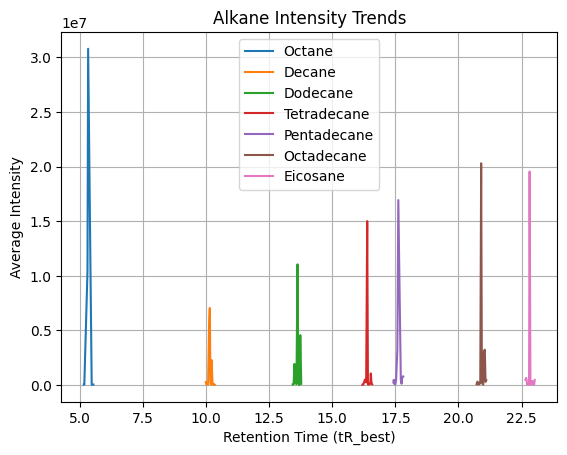

In [18]:
# Select only numeric intensity columns 
intensity_cols = cleaned_qc.select_dtypes(include='number').columns.difference(['Peak', 'tR_best', 'm/z'])

# Plot mean intensity for each matched compound
for compound in cleaned_qc['Matched_Compound'].unique():
    if compound != 'Unknown':
        subset = cleaned_qc[cleaned_qc['Matched_Compound'] == compound]
        avg_intensity = subset[intensity_cols].mean(axis=1)
        plt.plot(subset['tR_best'], avg_intensity, label=compound)

plt.xlabel('Retention Time (tR_best)')
plt.ylabel('Average Intensity')
plt.title('Alkane Intensity Trends')
plt.legend()
plt.grid(True)
plt.show() 

# QC Drift Correction 

In [26]:

alpha = 0.05  # p-value threshold for drift
frac = 0.2    # LOESS smoothing fraction

file_master = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\files\project file\GCMS Steamed 96 set 2024- Mastertable(Sheet1).csv"
file_qc = r"C:\Users\fatemehm\OneDrive - Royal HZPC Group\Desktop\internship\bio_rep1\msmetrix_data\cleaned_qc.csv"


master_table = pd.read_csv(file_master)
cleaned_qc = pd.read_csv(file_qc)

#Identify metadata and intensity columns
metadata_cols = ['Peak', 'tR_best', 'm/z']
intensity_cols = [c for c in cleaned_qc.columns if c not in metadata_cols]

# Normalize  names 
rename_map = {col: col.split()[-1] for col in intensity_cols}
cleaned_qc.rename(columns=rename_map, inplace=True)
intensity_cols = [rename_map[c] for c in intensity_cols]

# Convert wide to long format 
long_qc = cleaned_qc.melt(
    id_vars=metadata_cols,
    value_vars=intensity_cols,
    var_name="Filename",
    value_name="Intensity"
)

# Merge with injection order from master table
merged = master_table.merge(long_qc, on="Filename", how="inner")

# Ensure numeric types and remove missing values
merged['Intensity'] = pd.to_numeric(merged['Intensity'], errors='coerce')
merged = merged.dropna(subset=['Intensity', 'Injection_order'])

#  Prepare for correction
corrected = merged.copy()
corrected['Intensity'] = corrected['Intensity'].astype(float)
results = []

# Drift correction loop per peak 
for peak in merged['Peak'].unique():
    subset = merged[merged['Peak'] == peak].dropna(subset=['Intensity', 'Injection_order'])
    y = subset['Intensity'].values
    x = subset['Injection_order'].values

    if len(y) < 2 or len(np.unique(y)) == 1:
        continue  # Skip low-variation or single-point peaks

    #  DEBUG: Show injection order distribution for QCs
    if 'QC' in subset['Filename'].iloc[0]:
        print(f"\n QC Injection Order for Peak {peak}:")
        print(subset[['Filename', 'Injection_order']].sort_values('Injection_order').head(10))

    # Linear regression for drift detection 
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    slope = model.params[1]
    pvalue = model.pvalues[1]

    # LOESS correction if significant drift
    if pvalue < alpha:
        loess_fit = lowess(y, x, frac=frac, return_sorted=False)
        corrected_values = y - (loess_fit - loess_fit[0])
        corrected.loc[
            (corrected['Peak'] == peak) & (corrected['Filename'].isin(subset['Filename'])),
            'Intensity'
        ] = corrected_values
        corrected_flag = True
    else:
        corrected_flag = False

    results.append({
        'Peak': peak,
        'Slope': slope,
        'p-value': pvalue,
        'Corrected': corrected_flag
    })


drift_summary = pd.DataFrame(results).sort_values('p-value')


print("\ nDrift Correction Summary:")
print(drift_summary)

print("\nNumber of corrected peaks:")
print(drift_summary['Corrected'].value_counts())

print("\nPeaks with strong drift (p < 0.01):")
print(drift_summary[drift_summary['p-value'] < 0.01].head())


<>:83: SyntaxWarning: invalid escape sequence '\ '
<>:83: SyntaxWarning: invalid escape sequence '\ '
C:\Users\fatemehm\AppData\Local\Temp\ipykernel_12612\1831406784.py:83: SyntaxWarning: invalid escape sequence '\ '
  print("\ nDrift Correction Summary:")



 QC Injection Order for Peak 1:
              Filename  Injection_order
0     S96_QC1_B1_D1_T1                4
589   S96_QC2_B1_D1_T1                5
1178  S96_QC3_B1_D1_T1                6
1767  S96_QC4_B1_D1_T1                7
2356  S96_QC1_B1_D2_T1               36
2945  S96_QC2_B1_D2_T1               37
3534  S96_QC3_B1_D2_T1               38
4123  S96_QC4_B1_D2_T1               39
4712  S96_QC1_B1_D3_T1               66
5301  S96_QC2_B1_D3_T1               67

 QC Injection Order for Peak 2:
              Filename  Injection_order
1     S96_QC1_B1_D1_T1                4
590   S96_QC2_B1_D1_T1                5
1179  S96_QC3_B1_D1_T1                6
1768  S96_QC4_B1_D1_T1                7
2357  S96_QC1_B1_D2_T1               36
2946  S96_QC2_B1_D2_T1               37
3535  S96_QC3_B1_D2_T1               38
4124  S96_QC4_B1_D2_T1               39
4713  S96_QC1_B1_D3_T1               66
5302  S96_QC2_B1_D3_T1               67

 QC Injection Order for Peak 3:
              Filenam

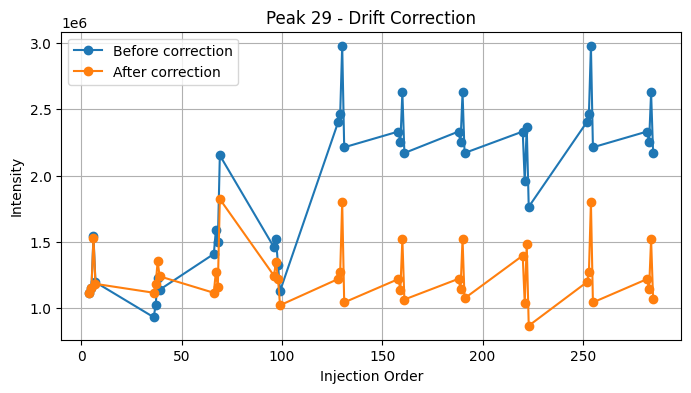

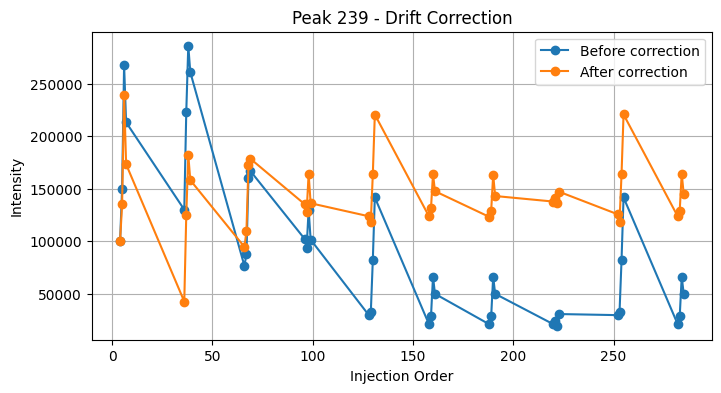

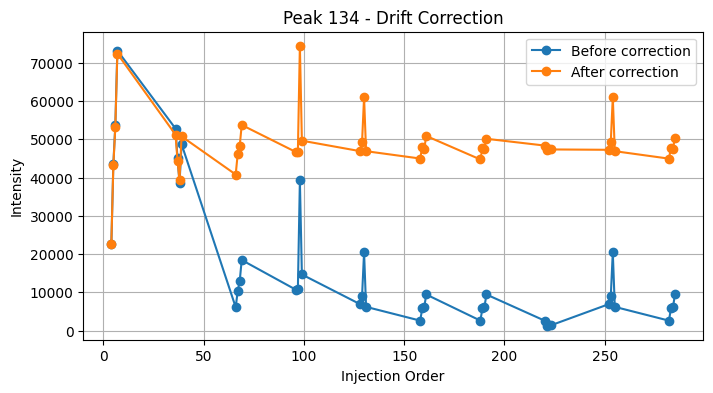

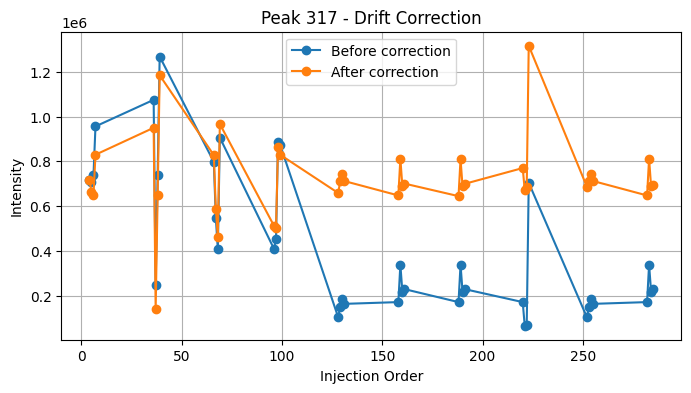

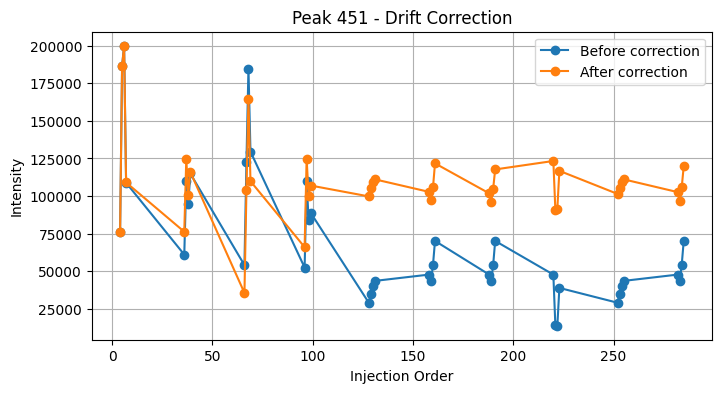

In [ ]:

# Pick top 5 most corrected peaks to show how the correction effecs on the drifts
top_peaks = drift_summary[drift_summary['Corrected']].nsmallest(5, 'p-value')['Peak']

for peak in top_peaks:
    before = merged[merged['Peak'] == peak]
    after = corrected[corrected['Peak'] == peak]
    
    plt.figure(figsize=(8,4))
    plt.plot(before['Injection_order'], before['Intensity'], 'o-', label='Before correction')
    plt.plot(after['Injection_order'], after['Intensity'], 'o-', label='After correction')
    plt.title(f"Peak {peak} - Drift Correction")
    plt.xlabel("Injection Order")
    plt.ylabel("Intensity")
    plt.legend()
    plt.grid(True)
    plt.show()


# QC preparation

In [ ]:
from sklearn.impute import KNNImputer
# Reshape corrected data to wide format 
wide_corrected = corrected.pivot_table(
    index=['Filename', 'Injection_order'],
    columns='Peak',
    values='Intensity',
    aggfunc='mean'
).reset_index()

# Separate metadata & features
metadata_cols = ['Filename', 'Injection_order']
feature_cols = [c for c in wide_corrected.columns if c not in metadata_cols]
intensities = wide_corrected[feature_cols].copy()

# QC-based feature filtering (RSD < 0.5) 
qc_mask = wide_corrected['Filename'].str.contains("QC", case=False, na=False)
qc_data = intensities[qc_mask]
rsd = qc_data.std(axis=0) / qc_data.mean(axis=0)
kept_features = rsd[rsd < 0.5].index
if len(kept_features) == 0:
    print("No features passed RSD filter. Using all features.")
    kept_features = intensities.columns
intensities = intensities[kept_features]
print(f"Features kept after RSD filtering: {len(kept_features)}")

# Probabilistic Quotient Normalization (PQN) 
qc_median = qc_data[kept_features].median(axis=0).replace(0, np.nan).fillna(qc_data[kept_features].mean())
quotients = intensities.div(qc_median, axis=1)
pqn_factors = quotients.median(axis=1).replace(0, np.nan).fillna(1)
intensities = intensities.div(pqn_factors, axis=0)

# Log transform (shifted to avoid negatives) ===
min_val = intensities.min().min()
shift = abs(min_val) + 1 if min_val <= 0 else 0
intensities = np.log1p(intensities + shift)

# KNN Imputation (if missing values exist) 
imputer = KNNImputer(n_neighbors=3)
intensities_imputed = imputer.fit_transform(intensities)
intensities = pd.DataFrame(intensities_imputed, columns=kept_features, index=wide_corrected.index)

# Autoscaling (z-score) 
scaler = StandardScaler()
intensities_scaled = scaler.fit_transform(intensities)
processed_features = pd.DataFrame(intensities_scaled, columns=kept_features, index=wide_corrected.index)

# Combine metadata + scaled features 
processed_data = pd.concat([wide_corrected[metadata_cols], processed_features], axis=1)
print(f"Processed samples shape: {processed_data.shape}")
display(processed_data.head())

Features kept after RSD filtering: 340
Processed samples shape: (40, 342)


Peak,Filename,Injection_order,1,4,5,6,7,8,9,12,...,568,570,572,578,580,581,582,584,586,588
0,S96_QC1_B1_D10_T1,282,0.107365,-0.524310,0.452820,-0.482685,-1.664195,0.082183,0.308655,-1.713385,...,-0.656338,-0.217908,0.044222,-0.105081,-0.436539,0.501009,-0.381975,0.090013,0.338488,0.215598
1,S96_QC1_B1_D1_T1,4,4.865394,4.650650,3.248888,3.420763,4.052558,1.462640,4.061714,1.948834,...,1.544980,-2.107622,2.028303,0.217873,-3.006397,3.706853,0.527782,1.493175,0.850025,-2.642116
2,S96_QC1_B1_D2_T1,36,0.138322,-0.331371,0.302977,-1.217424,-0.169563,2.010599,0.851479,-0.051440,...,-0.709213,-0.401783,-0.391437,-1.320370,-0.786252,-0.628738,-0.370042,-0.124061,-0.923332,0.155715
3,S96_QC1_B1_D3_T1,66,0.599383,-2.262373,0.345014,-1.135652,0.120617,1.488836,1.077249,-0.315300,...,-2.203518,-0.196392,-0.217101,0.887013,-1.945445,-1.882784,-0.469089,-0.193914,-0.613282,-0.970721
4,S96_QC1_B1_D4_T1,96,-2.092215,-1.131540,-0.592032,-1.334953,0.149733,1.469488,1.164960,0.250081,...,-1.917369,-0.627972,1.553498,1.650539,1.149319,0.687719,-0.413256,-0.281676,-0.289260,-1.019506


# Check QC performance



Top 20 contributing features to PC1:
Peak
528    0.081128
268    0.079783
505    0.079766
419    0.079473
176    0.079433
200    0.079430
150    0.079400
339    0.079354
281    0.079337
384    0.079337
378    0.079317
358    0.079253
434    0.079239
418    0.079167
258    0.079117
334    0.079091
239    0.079076
392    0.079076
247    0.079004
142    0.079004
Name: PC1_Loading, dtype: float64


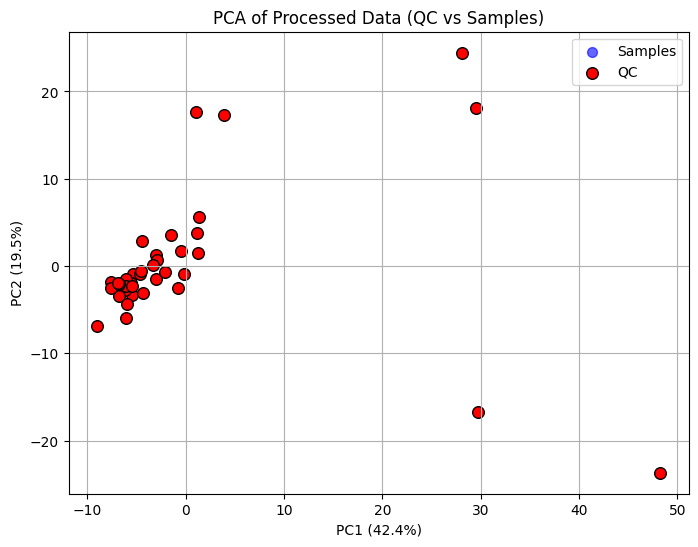

In [19]:
pca = PCA(n_components=2)
pca_scores = pca.fit_transform(processed_features)

# === 9. Feature contributions to PC1 ===
loadings = pd.Series(pca.components_[0], index=kept_features, name='PC1_Loading')
top20 = loadings.abs().sort_values(ascending=False).head(20)
print("Top 20 contributing features to PC1:")
print(top20)

# === 10. PCA Plot (QC vs Samples) ===
plt.figure(figsize=(8,6))
plt.scatter(
    pca_scores[~qc_mask,0], pca_scores[~qc_mask,1],
    c='blue', label='Samples', alpha=0.6, s=50
)
plt.scatter(
    pca_scores[qc_mask,0], pca_scores[qc_mask,1],
    c='red', label='QC', edgecolor='k', s=70
)
plt.title("PCA of Processed Data (QC vs Samples)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend()
plt.grid(True)
plt.show()

# flag/remove outlier and re‑process

In [20]:
outlier_idx = np.where((pca_scores[:,0] > 20) | (pca_scores[:,1] > 20))[0]
print(wide_corrected.iloc[outlier_idx][['Filename','Injection_order']])


Peak          Filename  Injection_order
1     S96_QC1_B1_D1_T1                4
11    S96_QC2_B1_D1_T1                5
21    S96_QC3_B1_D1_T1                6
31    S96_QC4_B1_D1_T1                7


In [21]:
from scipy.stats import spearmanr
corr, pval = spearmanr(wide_corrected['Injection_order'], pca_scores[:,0])
print(f"PC1 vs Injection order correlation: {corr:.2f} (p={pval:.4f})")


PC1 vs Injection order correlation: -0.34 (p=0.0326)


# Sample prepration

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# === Step 1: Pivot to wide format (sample x feature) ===
wide_corrected = corrected.pivot_table(
    index=['Filename', 'Injection_order'],
    columns='Peak',
    values='Intensity',
    aggfunc='mean'
).reset_index()

metadata_cols = ['Filename', 'Injection_order']
feature_cols = [c for c in wide_corrected.columns if c not in metadata_cols]

# Use previously selected QC-stable features
intensities = wide_corrected[kept_features].copy()

# === Step 2: PQN Normalization ===
qc_mask = wide_corrected['Filename'].str.contains("QC", case=False, na=False)
qc_data = intensities[qc_mask]
qc_median = qc_data.median(axis=0).replace(0, np.nan).fillna(qc_data.mean())

quotients = intensities.div(qc_median, axis=1)
pqn_factors = quotients.median(axis=1).replace(0, np.nan).fillna(1)
intensities = intensities.div(pqn_factors, axis=0)

# === Step 3: Log-transform (shift if needed to avoid log(0)) ===
shift = abs(intensities.min().min()) + 1
intensities = np.log1p(intensities + shift)

# === Step 4: KNN Imputation (if missing values exist) ===
imputer = KNNImputer(n_neighbors=3)
intensities_imputed = imputer.fit_transform(intensities)
intensities = pd.DataFrame(intensities_imputed, columns=kept_features, index=wide_corrected.index)

# === Step 5: Autoscaling (Z-score) ===
scaler = StandardScaler()
intensities_scaled = scaler.fit_transform(intensities)
processed_features_scaled = pd.DataFrame(intensities_scaled, columns=kept_features, index=wide_corrected.index)

# === Step 6: Add metadata back ===
processed_samples = pd.concat([wide_corrected[metadata_cols], processed_features_scaled], axis=1)

print(f"Final sample matrix shape: {processed_samples.shape}")
processed_samples.head()


Final sample matrix shape: (39, 349)


Peak,Filename,Injection_order,1,3,4,6,8,9,14,15,...,522,525,526,527,528,533,536,537,539,541
0,S96_QC1_B1_D10_T1,282,-0.041123,-0.505238,-0.371755,-0.559332,0.369019,-0.137528,-0.937320,-0.500300,...,-0.129467,-0.619085,0.035706,-0.726973,-0.327233,-1.201045,-0.434223,-0.137194,-0.165588,-0.236137
1,S96_QC1_B1_D1_T1,4,5.544958,4.860380,4.003157,4.269772,3.925525,5.368996,3.335310,5.323959,...,-0.849826,2.078921,5.394634,2.608641,4.023047,1.147082,3.932452,-1.989962,1.213776,0.716661
2,S96_QC1_B1_D2_T1,36,-0.057463,-0.331886,-0.885430,-0.609914,0.333150,0.034704,-0.166231,0.318086,...,-0.258722,-0.610484,-0.520120,-0.647254,-0.354870,-1.275541,-0.628417,-0.164652,-0.156386,-1.166148
3,S96_QC1_B1_D3_T1,66,0.085197,-0.892073,-0.903028,-0.824633,1.335873,0.701669,-0.490731,0.029275,...,-0.524033,-0.634456,-0.128251,0.438716,-0.684127,0.805774,-0.962635,-0.423656,-0.518590,-0.128945
4,S96_QC1_B1_D4_T1,96,-2.190067,-0.831267,-1.073149,-1.403775,0.549384,1.262402,0.649629,0.185799,...,-0.231933,-0.621954,0.125347,0.604430,-0.649726,1.579066,0.010443,-0.168718,-0.321651,-0.444469


# Feature importance & discrimination

In [23]:
from sklearn.decomposition import PCA
import pandas as pd

# === Separate features (exclude metadata that exist) ===
metadata_cols = ['Filename', 'Injection_order']  # Only keep those that exist
features = processed_data.drop(columns=metadata_cols)

# === Run PCA ===
pca = PCA(n_components=2)
pca.fit(features)

# === Get loadings for PC1 (importance of each feature) ===
loadings = pd.Series(
    pca.components_[0],
    index=features.columns,
    name="PC1_Loading"
)

# Sort by absolute importance
top_features = loadings.abs().sort_values(ascending=False).head(20)

print("Top 20 contributing features to PC1:")
print(top_features)


Top 20 contributing features to PC1:
Peak
528    0.081128
268    0.079783
505    0.079766
419    0.079473
176    0.079433
200    0.079430
150    0.079400
339    0.079354
281    0.079337
384    0.079337
378    0.079317
358    0.079253
434    0.079239
418    0.079167
258    0.079117
334    0.079091
239    0.079076
392    0.079076
247    0.079004
142    0.079004
Name: PC1_Loading, dtype: float64


# Anova by sample id

In [24]:
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Extract grouping: SampleID (XX)
groups = processed_data['Filename'].str.extract(r"S96_(\d+)_")[0]
groups = groups.fillna('QC')

features = processed_data.drop(columns=['Filename','Injection_order'])

# Perform ANOVA
p_values = []
for col in features.columns:
    group_values = [features[groups == g][col].dropna() for g in groups.unique() if len(features[groups == g]) > 1]
    if len(group_values) >= 2:  # need at least 2 groups with >1 sample each
        stat, p = f_oneway(*group_values)
    else:
        p = 1.0
    p_values.append(p)

# Store results
anova_results = pd.Series(p_values, index=features.columns)
significant_features = anova_results[anova_results < 0.05]

print(f"Number of significant features: {len(significant_features)}")


Number of significant features: 0


we can use this subset of peaks for:

PLS‑DA

Clustering (heatmaps)

Correlation networks

Merging with genetic data (for GWAS)

Biological interpretation (KEGG, MetaboAnalyst).

# PLS‑DA

In [25]:


# Prepare Y (one-hot encoded SampleID)
Y = OneHotEncoder(sparse=False).fit_transform(groups.values.reshape(-1,1))

# Fit PLS-DA
pls = PLSRegression(n_components=2)
pls.fit(features, Y)
scores = pls.transform(features)

# Plot PLS-DA scores
plt.figure(figsize=(8,6))
for sample_id in np.unique(groups):
    idx = groups == sample_id
    plt.scatter(scores[idx,0], scores[idx,1], label=f"ID {sample_id}")
plt.xlabel("PLS-DA Component 1")
plt.ylabel("PLS-DA Component 2")
plt.title("PLS-DA: Separation by SampleID")
plt.legend()
plt.grid(True)
plt.show()


TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [ ]:
def calculate_vip(pls, X):
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_
    p, h = w.shape
    s = np.diag(t.T @ t @ q.T @ q).reshape(h, -1)
    total_s = np.sum(s)
    vip = np.sqrt(p * (w**2 @ s) / total_s).ravel()
    return vip

vip_scores = calculate_vip(pls, features)
vip_series = pd.Series(vip_scores, index=features.columns).sort_values(ascending=False)
print(vip_series.head(20))  # Top discriminating metabolites


# Hierarchical Clustering Heatmap (Top VIP compounds)

In [ ]:

# Select top 20 VIP compounds
top_features = vip_series.head(20).index
subset = features[top_features]

# Create clustered heatmap
sns.clustermap(subset, method='ward', cmap='vlag', figsize=(12,8), 
               row_cluster=True, col_cluster=True,
               xticklabels=False, yticklabels=top_features)
plt.title("Hierarchical Clustering of Top VIP Compounds")
plt.show()


# Metabolite Relationships

In [ ]:


# Correlation matrix for top VIP features
corr = subset.corr()

# Create edges for |r| > 0.7
edges = [(i, j, corr.loc[i,j]) for i in corr.columns for j in corr.columns 
         if abs(corr.loc[i,j]) > 0.7 and i != j]

# Build network
G = nx.Graph()
for i,j,w in edges:
    G.add_edge(i, j, weight=w)

# Draw network
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=800, font_size=8,
        node_color='skyblue', edge_color='gray')
plt.title("Correlation Network of Top VIP Compounds (|r| > 0.7)")
plt.show()
